# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [3]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [5]:
df.isna().sum()

Make                  0
Model                 0
Year                  0
Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Number of Doors       6
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(720)

In [7]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [8]:
df.shape

(11914, 15)

In [16]:

df[df['Engine Fuel Type'].isna()]
df[df['Number of Doors'].isna()]


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
4666,Ferrari,FF,2013,premium unleaded (required),651.0,12.0,AUTOMATED_MANUAL,all wheel drive,NaN,Large,Coupe,16,11,2774,295000
6930,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,105,102,1391,79500
6931,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,101,98,1391,66000
6932,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,105,92,1391,134500
6933,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,rear wheel drive,NaN,Large,Sedan,100,97,1391,74500
6934,Tesla,Model S,2016,electric,NaN,0.0,DIRECT_DRIVE,all wheel drive,NaN,Large,Sedan,107,101,1391,71000


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Duplicate rows|df.duplicated().sum() |720 | removed duplicates|Same cars were being counted more than once |
| 2 | Missing HP for non-electric cars| Checked missing Engine HP and fuel type| 25| Flagged missing HP|Non-electric cars should normally have an HP value |
| 3 | highway MPG |Checked high MPG for non-electric cars |1 |Set it to NaN| 354 highway MPG is unrealistic for a gas car
| 4 | Missing Engine Fuel Type | Checked missing fuel types |3 |Left as NaN | Fuel type is missing for 3 Suzuki Verona cars
| 5 | Missing Number of Doors |Checked missing door values | 6 | Left as NaN | Door information is missing for 6 cars |

In [17]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [18]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11914, 15)
engine_fuel_type     3
engine_hp           69
engine_cylinders    30
number_of_doors      6
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

40594.737032063116
29995.0


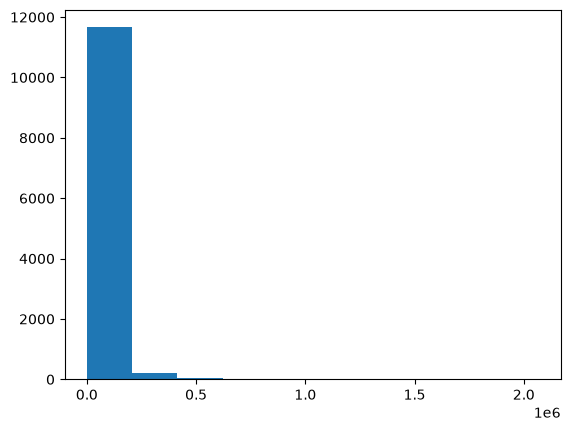

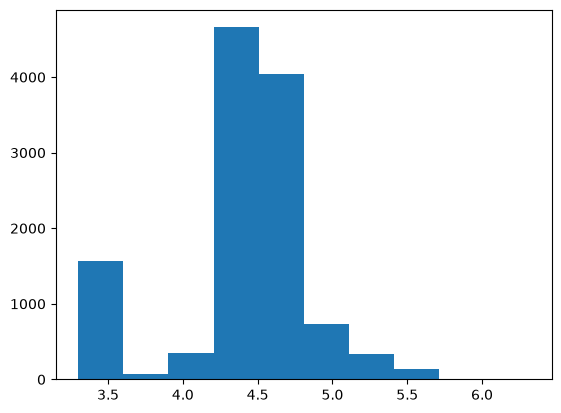

27.438307873090483


In [19]:
# a) mean and median
mean_msrp =clean['msrp'].mean()
median_msrp = clean['msrp'].median()
print(mean_msrp)
print(median_msrp)
# b) two histograms side by side (plt.subplots(1, 2))
import matplotlib.pyplot as plt
plt.hist(clean['msrp'])
plt.show()
plt.hist(np.log10(clean['msrp']))
plt.show()

# The first graph a lot of cars are clustered at the lower prices on the left, but a few extremely expensive cars stretch the graph far to the right.
# The second graph is more balanced and taking the log reduces the effect of those expensive cars, so you can see the main distribution much better.

# c) share of cars above the mean
car_mean = (clean['msrp'] > mean_msrp).mean() * 100
print(car_mean)



**Answer:** the median price because there are a few very expensive cars that increase the mean.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [20]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars = clean[clean['year'] ==  2017]
cars.groupby('vehicle_size')['highway_mpg'].agg(['mean', 'std'])
# b) z = (value - class mean) / class std
zscore_compact = (42 - 31.833333) / 10.697106
zscore_large = (34 - 22.943158) / 3.502099
print(zscore_compact)
print(zscore_large)

0.9504128499801723
3.157204293767823


**Answer:** 
The Volvo is more fuel-efficient for its size because its z-score is 3.15, while the Civic's is 0.95. The Civic has good MPG compared to other compact cars, but the Volvo's MPG is much higher compared to other large cars.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

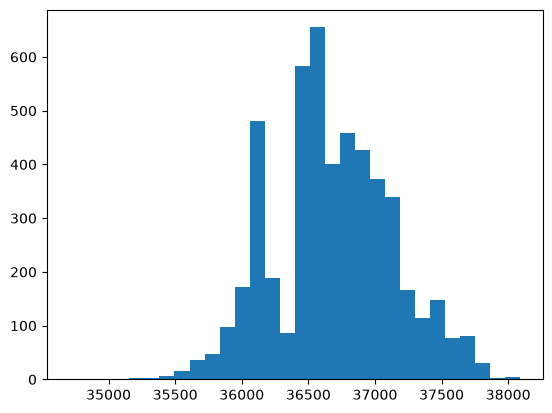

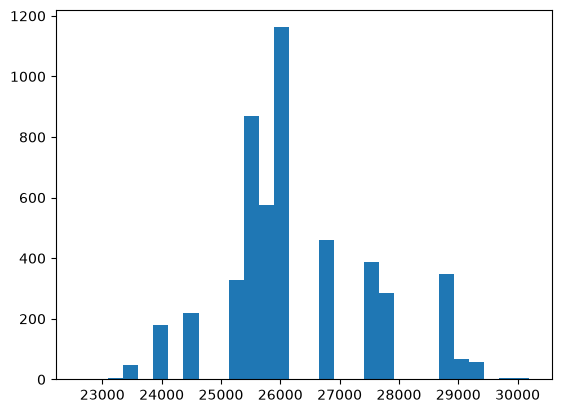

array([24095., 28995.])

In [42]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    pass

# a, b)
    cars_2017 = clean[clean['year'] == 2017]
    median_msrp = cars_2017['msrp'].median()

    medians = []

    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        median = np.median(sample)
        medians.append(median)

    return np.array(medians)

cars_2017 = clean[clean['year'] == 2017]

prices_2017 = cars_2017['msrp'].to_numpy()

boot_median = bootstrap_median(prices_2017)

plt.hist(boot_median, bins=30)
plt.show()

np.percentile(boot_median, [2.5, 97.5])
# c)
cars_2017['make'].value_counts()

subaru_2017 = cars_2017[cars_2017['make'] == 'Subaru']
subaru_prices = subaru_2017['msrp'].to_numpy()

subaru_boot_medians = bootstrap_median(subaru_prices)
plt.hist(subaru_boot_medians, bins=30)
plt.show()

np.percentile(subaru_boot_medians, [2.5, 97.5])

#d  
# We are 95% confident that the median price of 2017 cars is between $23,995 and $28,995.



**Answer:**

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

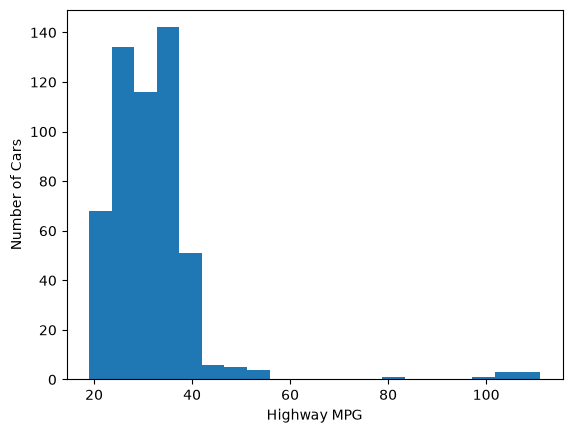

TtestResult(statistic=np.float64(3.096200618564181), pvalue=np.float64(0.0013106660623769784), df=np.int64(89))

In [ ]:
# a) H₀: The average highway MPG of 2017 compact cars is 30 MPG. Hₐ: The average highway MPG is greater than 30 MPG. This is a one-sided test because we are testing whether the average is greater than 30, not just different from 30.
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = cars_2017[cars_2017['vehicle_size'] == 'Compact']
len(compact_2017)

plt.hist(compact_2017['highway_mpg'], bins=20)
plt.xlabel('Highway MPG')
plt.ylabel('Number of Cars')
plt.show()

# There are 534 cars in the sample. The distribution is right-skewed because a few cars have very high MPG values. Since the sample is large, the t-test is still reasonable.

# c) one-sample t-test vs 30
stats.ttest_1samp(compact_2017['highway_mpg'], 30, alternative='greater') 

# The p-value is less than 0.05, so there is enough evidence to conclude that 2017 compact cars average more than 30 highway MPG.

# d) rows per make+model, then one row per model and retest
model_mpg = compact_2017.groupby(['make', 'model'])['highway_mpg'].mean()
len(model_mpg)
stats.ttest_1samp(model_mpg, 30, alternative='greater')

# After averaging to one row per model, the p-value increased and still below 0.05. The model-level test I trust better because different versions of the same model should not be treated as completely independent cars.

**Answer:**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [52]:
# a) compare median MSRP by transmission type
clean['transmission_type'].value_counts()

automatic = clean[clean['transmission_type'] == 'AUTOMATIC']
manual = clean[clean['transmission_type'] == 'MANUAL']

automatic_median = automatic['msrp'].median()
manual_median = manual['msrp'].median()
print(automatic_median)
print(manual_median)

# b) compare year by transmission type
automatic_year = automatic['year'].median()
manual_year = manual['year'].median()

print(automatic_year)
print(manual_year)

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
recent = clean[clean['year'].between(2015,2017)]
recent.groupby(['vehicle_size', 'transmission_type'])['msrp'].median()

recent_compact = recent[recent['vehicle_size'] == 'Compact']
auto = recent_compact[recent_compact['transmission_type'] == 'AUTOMATIC']['msrp']
manual = recent_compact[recent_compact['transmission_type'] == 'MANUAL']['msrp']

stats.mannwhitneyu(auto, manual)

# The median suggests manual cars are cheaper, but the p-value of 0.094 shows the difference is not statistically significant.

#d 
#Manual cars look cheaper overall, but when comparing newer compact cars, there is not enough evidence to say manual cars are actually cheaper than automatic cars.

32565.0
18720.0
2015.0
2008.0


MannwhitneyuResult(statistic=np.float64(346203.0), pvalue=np.float64(0.0941621665794619))

**Answer:**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [78]:
# a) Welch t-test, 4-door vs 2-door
four_door = clean[clean['number_of_doors'] == 4]['highway_mpg']
two_door = clean[clean['number_of_doors'] == 2]['highway_mpg']

four_mean = four_door.mean()
two_mean = two_door.mean()

difference = four_mean - two_mean

print(four_mean)
print(two_mean)
print(difference)

test = stats.ttest_ind(four_door, two_door, equal_var=False)
print(test)

# 4-door cars average about 2.08 more highway MPG than 2-door cars. The p-value is less than 0.05, so the difference is statistically significant.

# b) yearly gas cost = miles * price_per_gallon / mpg
four_cost = 12000 * 3.50 / four_mean
two_cost = 12000 * 3.50 / two_mean
savings = two_cost - four_cost

print(savings)

# The average 4-door driver saves about $125.48 per year on gas compared to the average 2-door driver.
# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    sample_four = rng.choice(four_door, 30, replace=False)
    sample_two = rng.choice(two_door, 30, replace=False)

    test = stats.ttest_ind(sample_four, sample_two, equal_var=False)

    if test.pvalue < 0.05:
        hits += 1

fraction = hits / n_sims
print(fraction)



27.431701185202922
25.35379746835443
2.0779037168484926
TtestResult(statistic=np.float64(13.524257830649386), pvalue=np.float64(3.086680008864471e-41), df=np.float64(8253.43265348244))
125.48128348037221
0.145


**Answer:**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

In [ ]:
# Manual cars are cheaper with a median price of $18,720 compared to $32,565 for automatic cars. When comparing 2015–2017 compact cars, 
# there was not enough evidence to say manual cars are actually cheaper. We also found that the year and size of a car can affect its price. One limitation is 
# that the dataset includes cars from many different years, which can make price comparisons less accurate.

**Memo:**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2